# RECOMMENDATION SYSTEM PROJECT

### loading of the data and cleaning it.

In [2]:
import pandas as pd

In [3]:
# load the dataset
df = pd.read_csv('..\data\movies.csv')
df.head(10)


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy
5,6,Heat (1995),Action|Crime|Thriller
6,7,Sabrina (1995),Comedy|Romance
7,8,Tom and Huck (1995),Adventure|Children
8,9,Sudden Death (1995),Action
9,10,GoldenEye (1995),Action|Adventure|Thriller


In [4]:
# checking the info of the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9742 entries, 0 to 9741
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   movieId  9742 non-null   int64 
 1   title    9742 non-null   object
 2   genres   9742 non-null   object
dtypes: int64(1), object(2)
memory usage: 228.5+ KB


there are 9742 rows,3 columns ,the datatype  is an one integer and two objects,there are no missing values.

In [5]:
df.isnull().sum()

movieId    0
title      0
genres     0
dtype: int64

In [6]:
df.describe()

,movieId
count,9742.000000
mean,42200.353623
std,52160.494854
min,1.000000
25%,3248.250000
50%,7300.000000
75%,76232.000000
max,193609.000000


In [7]:
# finding out if there are any duplicates in the dataset
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
9737    False
9738    False
9739    False
9740    False
9741    False
Length: 9742, dtype: bool

shows if there are no duplicates in the dataset.

In [8]:
# extracting the year from the title column
df['year'] = df['title'].str.extract(r'\((\d{4})\)')
df['year'] = df['year'].astype("float")
df['year'].head()

0    1995.0
1    1995.0
2    1995.0
3    1995.0
4    1995.0
Name: year, dtype: float64

In [9]:
df['year'].describe()

count    9729.000000
mean     1994.613629
std        18.535219
min      1902.000000
25%      1988.000000
50%      1999.000000
75%      2008.000000
max      2018.000000
Name: year, dtype: float64

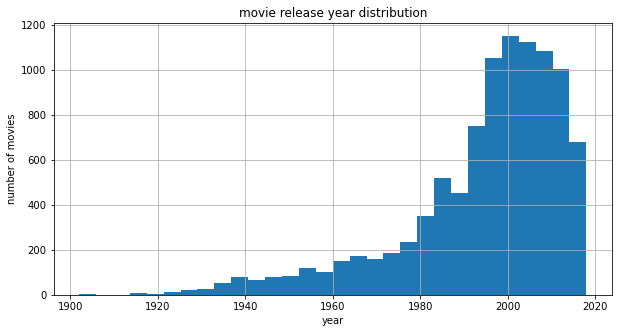

In [10]:
import matplotlib.pyplot as plt
df['year'].dropna().hist(bins=30, figsize=(10,5))
plt.title('movie release year distribution')
plt.xlabel('year')
plt.ylabel('number of movies')
plt.show()


alot of movies were released in between the late 90's and the early 2000

In [11]:
combo_counts = df['genres'].value_counts()
combo_counts.head(10)

Drama                   1053
Comedy                   946
Comedy|Drama             435
Comedy|Romance           363
Drama|Romance            349
Documentary              339
Comedy|Drama|Romance     276
Drama|Thriller           168
Horror                   167
Horror|Thriller          135
Name: genres, dtype: int64

from this we see that the comedy|drama genre combination has the highest amount of movies as well as the comedy|romance. while drama and comedy genres are the most dominate genres.

In [12]:
# split the genres column in multiple columns
df['genres'] = df['genres'].str.split('|')

In [13]:
# number of  genres per movie
df['num_genres'] = df['genres'].apply(len)
df['num_genres'].head()


0    5
1    3
2    2
3    3
4    1
Name: num_genres, dtype: int64

In [14]:
df['num_genres'].describe()

count    9742.000000
mean        2.266886
std         1.123249
min         1.000000
25%         1.000000
50%         2.000000
75%         3.000000
max        10.000000
Name: num_genres, dtype: float64

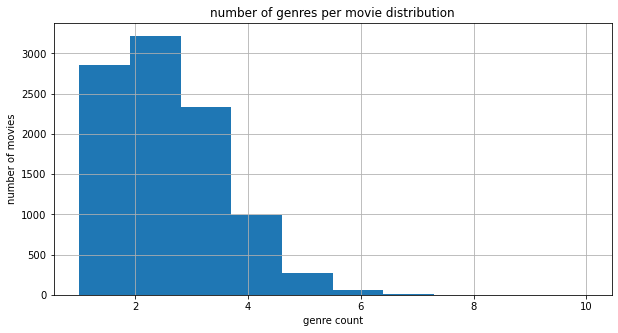

In [15]:
df['num_genres'].hist(bins=10, figsize=(10,5))
plt.title('number of genres per movie distribution')
plt.xlabel('genre count')
plt.ylabel('number of movies')
plt.show()

most movies that have less than 3 genres are more than those with more genres.

In [16]:
df.head()

,movieId,title,genres,year,num_genres
0,1,Toy Story (1995),"[Adventure, Animation, Children, Comedy, Fantasy]",1995.0,5
1,2,Jumanji (1995),"[Adventure, Children, Fantasy]",1995.0,3
2,3,Grumpier Old Men (1995),"[Comedy, Romance]",1995.0,2
3,4,Waiting to Exhale (1995),"[Comedy, Drama, Romance]",1995.0,3
4,5,Father of the Bride Part II (1995),[Comedy],1995.0,1


In [17]:
from collections import Counter

genre_counts = Counter(
    genre for genres in df["genres"] for genre in genres
)

genre_df = pd.DataFrame(
    genre_counts.items(), columns=["Genre", "Count"]
).sort_values(by="Count", ascending=False)

genre_df

,Genre,Count
6,Drama,4361
3,Comedy,3756
9,Thriller,1894
7,Action,1828
5,Romance,1596
0,Adventure,1263
8,Crime,1199
12,Sci-Fi,980
10,Horror,978
4,Fantasy,779


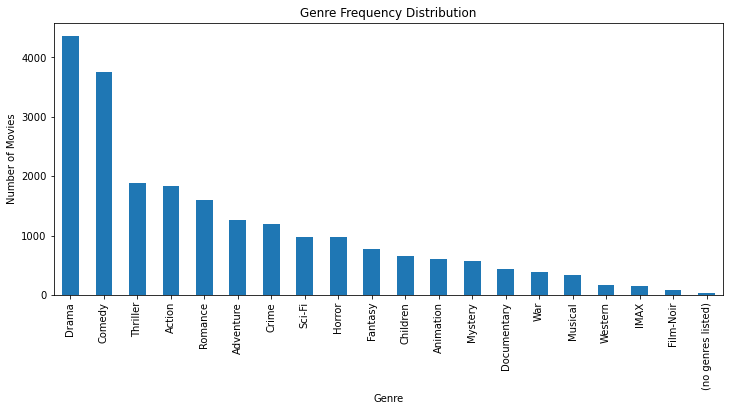

In [18]:
genre_df.plot(
    kind="bar",
    x="Genre",
    y="Count",
    figsize=(12,5),
    legend=False
)
plt.title("Genre Frequency Distribution")
plt.ylabel("Number of Movies")
plt.show()

genres like drama and comedy have the most amount of movies while those like western and IMAX have less movies.

In [19]:
# removing the no genres lised column
df[df['genres'].apply(lambda x: 'no genres listed' not in x)]


,movieId,title,genres,year,num_genres
0,1,Toy Story (1995),"[Adventure, Animation, Children, Comedy, Fantasy]",1995.0,5
1,2,Jumanji (1995),"[Adventure, Children, Fantasy]",1995.0,3
2,3,Grumpier Old Men (1995),"[Comedy, Romance]",1995.0,2
3,4,Waiting to Exhale (1995),"[Comedy, Drama, Romance]",1995.0,3
4,5,Father of the Bride Part II (1995),[Comedy],1995.0,1
...,...,...,...,...,...
9737,193581,Black Butler: Book of the Atlantic (2017),"[Action, Animation, Comedy, Fantasy]",2017.0,4
9738,193583,No Game No Life: Zero (2017),"[Animation, Comedy, Fantasy]",2017.0,3
9739,193585,Flint (2017),[Drama],2017.0,1
9740,193587,Bungo Stray Dogs: Dead Apple (2018),"[Action, Animation]",2018.0,2


In [21]:
rating_df = pd.read_csv('../data/ratings.csv')
rating_df.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [24]:
rating_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100836 non-null  int64  
 1   movieId    100836 non-null  int64  
 2   rating     100836 non-null  float64
 3   timestamp  100836 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 3.1 MB


In [23]:
df.merge(rating_df, on='movieId')

,movieId,title,genres,year,num_genres,userId,rating,timestamp
0,1,Toy Story (1995),"[Adventure, Animation, Children, Comedy, Fantasy]",1995.0,5,1,4.0,964982703
1,1,Toy Story (1995),"[Adventure, Animation, Children, Comedy, Fantasy]",1995.0,5,5,4.0,847434962
2,1,Toy Story (1995),"[Adventure, Animation, Children, Comedy, Fantasy]",1995.0,5,7,4.5,1106635946
3,1,Toy Story (1995),"[Adventure, Animation, Children, Comedy, Fantasy]",1995.0,5,15,2.5,1510577970
4,1,Toy Story (1995),"[Adventure, Animation, Children, Comedy, Fantasy]",1995.0,5,17,4.5,1305696483
...,...,...,...,...,...,...,...,...
100831,193581,Black Butler: Book of the Atlantic (2017),"[Action, Animation, Comedy, Fantasy]",2017.0,4,184,4.0,1537109082
100832,193583,No Game No Life: Zero (2017),"[Animation, Comedy, Fantasy]",2017.0,3,184,3.5,1537109545
100833,193585,Flint (2017),[Drama],2017.0,1,184,3.5,1537109805
100834,193587,Bungo Stray Dogs: Dead Apple (2018),"[Action, Animation]",2018.0,2,184,3.5,1537110021
